# HPV Alignment Validation Notebook
### Pre-BEAST Quality Control for `hpv_aligned_mafft.fasta`

| # | Check | What it catches |
|---|---|---|
| 1 | Basic stats | Sequence count, alignment length |
| 2 | Header & metadata | Dates, precision tiers, countries |
| 3 | Date precision audit | Year/month/day breakdown, artificial date handling |
| 4 | Gap analysis | Per-sequence and per-column gap fractions |
| 5 | Sequence composition | GC content, ambiguity characters |
| 6 | Pairwise diversity | Within-type divergence, outlier detection |
| 7 | Column conservation | Invariant sites, hypervariable regions |
| 8 | BEAST readiness | Duplicate check, tip label format, temporal signal |

---
> **Date precision note:** Year-only dates are set to `YYYY-07-01`, month-only to `YYYY-MM-15`.
> The temporal signal section accounts for this — sequences are grouped by precision tier
> and only exact dates are used for the regression.

In [1]:
!pip install -q Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00


In [2]:
# ── SETUP ──────────────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from Bio import AlignIO
from collections import Counter
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

FASTA_PATH = 'hpv_aligned_mafft.fasta'

# Thresholds
GAP_WARN  = 0.30
GAP_FAIL  = 0.50
AMB_WARN  = 0.05
DIV_WARN  = 0.20

print('Libraries loaded. Ready to run validation.')

Libraries loaded. Ready to run validation.


---
## Section 1 — Basic Alignment Statistics

In [3]:
aln = AlignIO.read(FASTA_PATH, 'fasta')
n_seq   = len(aln)
aln_len = aln.get_alignment_length()
seqs_list = [str(r.seq).upper() for r in aln]

print('=' * 55)
print('  ALIGNMENT BASIC STATISTICS')
print('=' * 55)
print(f'  Number of sequences   : {n_seq}')
print(f'  Alignment length (bp) : {aln_len:,}')

HPV_GENOME = 7904
if aln_len < HPV_GENOME * 0.8:
    print(f'  ⚠  Shorter than expected (HPV ~{HPV_GENOME} bp)')
elif aln_len > HPV_GENOME * 1.5:
    print(f'  ⚠  Much longer than expected — check for inserted regions')
else:
    print(f'  ✓  Alignment length within expected HPV range')

if n_seq < 10:
    print(f'  ⚠  Fewer than 10 sequences')
else:
    print(f'  ✓  Sequence count adequate ({n_seq})')
print('=' * 55)

  ALIGNMENT BASIC STATISTICS
  Number of sequences   : 566
  Alignment length (bp) : 8,988
  ✓  Alignment length within expected HPV range
  ✓  Sequence count adequate (566)


---
## Section 2 — Header & Metadata

In [4]:
# ── PARSE HEADERS ──────────────────────────────────────────────────────────
# Expected format: ACCESSION | HPV type | YYYY-MM-DD | precision | Country
date_pattern = re.compile(r'(\d{4})-(\d{2})-(\d{2})')

parsed = []   # list of dicts, one per sequence
for rec in aln:
    desc  = rec.description
    parts = [p.strip() for p in desc.split('|')]

    accession = parts[0] if parts else rec.id
    hpv_type  = parts[1] if len(parts) > 1 else 'Unknown'
    date_str  = parts[2] if len(parts) > 2 else ''
    precision = parts[3].lower() if len(parts) > 3 else 'unknown'
    country   = parts[4] if len(parts) > 4 else 'Unknown'

    m = date_pattern.search(date_str)
    year  = int(m.group(1)) if m else None
    month = int(m.group(2)) if m else None
    day   = int(m.group(3)) if m else None

    # Decimal year — exact where possible, midpoint otherwise
    if year:
        decimal = year + (month - 1) / 12.0 + (day - 1) / 365.0
    else:
        decimal = None

    parsed.append({
        'id':        accession,
        'type':      hpv_type,
        'year':      year,
        'month':     month,
        'day':       day,
        'decimal':   decimal,
        'precision': precision,
        'country':   country,
    })

df = pd.DataFrame(parsed)

missing_date = df[df['year'].isna()]
valid_years  = df['year'].dropna().astype(int)

print('=' * 55)
print('  METADATA SUMMARY')
print('=' * 55)
print(f'  Sequences with dates  : {df["year"].notna().sum()} / {n_seq}')
print(f'  Missing dates         : {len(missing_date)}')
if len(missing_date):
    print(f'  ⚠  Missing: {list(missing_date["id"])[:5]}')
else:
    print('  ✓  All sequences have dates')

print(f'  Date range            : {valid_years.min()} – {valid_years.max()}')
print(f'  Temporal span         : {valid_years.max() - valid_years.min()} years')

print(f'\n  HPV types:')
for t, c in Counter(df['type']).most_common():
    print(f'    {t}: {c}')

print(f'\n  Countries ({df["country"].nunique()} unique):')
for c, n in Counter(df['country']).most_common(10):
    print(f'    {c}: {n}')
print('=' * 55)

  METADATA SUMMARY
  Sequences with dates  : 566 / 566
  Missing dates         : 0
  ✓  All sequences have dates
  Date range            : 2001 – 2025
  Temporal span         : 24 years

  HPV types:
    Human papillomavirus type 16: 431
    Human papillomavirus 16: 135

  Countries (19 unique):
    United Kingdom: 256
    Netherlands: 110
    France: 33
    Japan: 27
    Russia: 18
    Nepal: 17
    Cambodia: 16
    Thailand: 15
    Latvia: 15
    Brazil: 13


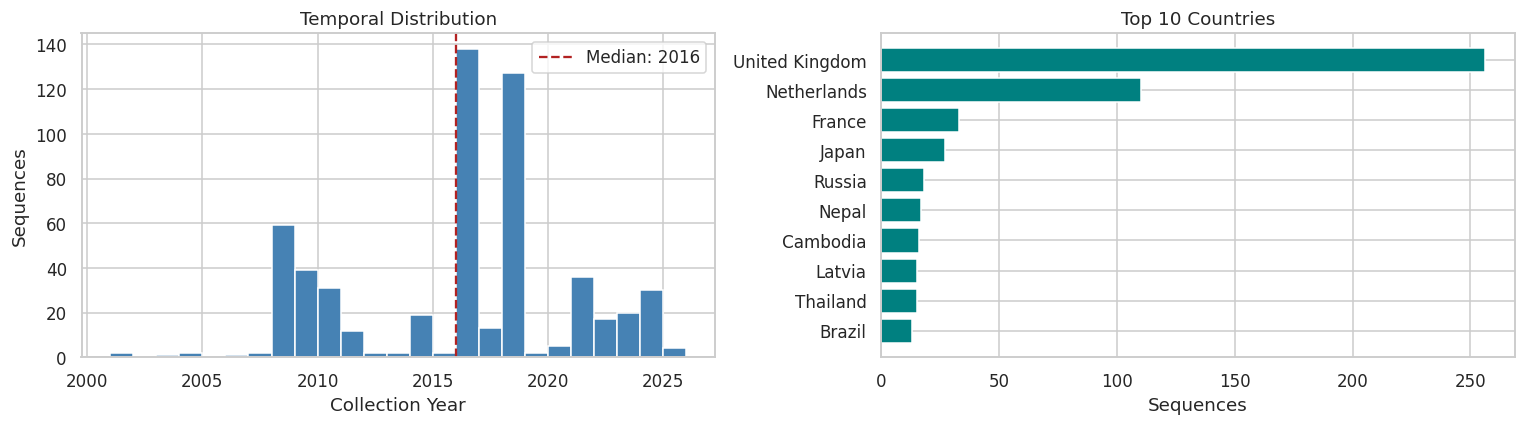

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(valid_years, bins=range(int(valid_years.min()), int(valid_years.max())+2),
             color='steelblue', edgecolor='white')
axes[0].axvline(valid_years.median(), color='firebrick', linestyle='--',
                label=f'Median: {int(valid_years.median())}')
axes[0].set_xlabel('Collection Year')
axes[0].set_ylabel('Sequences')
axes[0].set_title('Temporal Distribution')
axes[0].legend()

top_countries = df['country'].value_counts().head(10)
axes[1].barh(top_countries.index, top_countries.values, color='teal')
axes[1].set_xlabel('Sequences')
axes[1].set_title('Top 10 Countries')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig1_metadata.png', bbox_inches='tight')
plt.show()

---
## Section 3 — Date Precision Audit

Dates were assigned at three precision tiers:
- **`year`** → collection year only → assigned `YYYY-07-01` (July 1st midpoint)
- **`month`** → year + month → assigned `YYYY-MM-15` (15th midpoint)
- **`day`** → exact collection date → used as-is

This section audits the breakdown and explains its implications for temporal signal testing.

In [6]:
prec_counts = df['precision'].value_counts()

print('=' * 60)
print('  DATE PRECISION BREAKDOWN')
print('=' * 60)
for prec, cnt in prec_counts.items():
    pct = cnt / n_seq * 100
    note = ''
    if prec == 'year':
        note = '  → assigned July 1st'
    elif prec == 'month':
        note = '  → assigned 15th of month'
    elif prec == 'day':
        note = '  → exact date'
    print(f'  {prec:<10}: {cnt:>4} sequences ({pct:.1f}%){note}')

year_only_pct = prec_counts.get('year', 0) / n_seq * 100
exact_count   = prec_counts.get('day', 0)

print()
print(f'  Unique decimal year values in dataset: {df["decimal"].nunique()}')
print(f'  (vs {n_seq} sequences — ties expected due to artificial midpoints)')
print()

if year_only_pct > 80:
    print(f'  ⚠  {year_only_pct:.0f}% of sequences have year-only precision.')
    print(f'     This is EXPECTED and does not affect BEAST.')
    print(f'     BEAST uses the assigned dates as tip calibrations.')
    print(f'     The molecular clock rate will have wider uncertainty')
    print(f'     than if all dates were exact — acceptable for a student project.')
print()
print(f'  Sequences with exact dates (day-precision): {exact_count}')
if exact_count >= 10:
    print(f'  ✓  Enough exact dates for a meaningful temporal signal test')
else:
    print(f'  ⚠  Few exact dates — temporal signal test will use all sequences')
    print(f'     but interpret results cautiously')
print('=' * 60)

  DATE PRECISION BREAKDOWN
  year      :  516 sequences (91.2%)  → assigned July 1st
  day       :   38 sequences (6.7%)  → exact date
  month     :   12 sequences (2.1%)  → assigned 15th of month

  Unique decimal year values in dataset: 62
  (vs 566 sequences — ties expected due to artificial midpoints)

  ⚠  91% of sequences have year-only precision.
     This is EXPECTED and does not affect BEAST.
     BEAST uses the assigned dates as tip calibrations.
     The molecular clock rate will have wider uncertainty
     than if all dates were exact — acceptable for a student project.

  Sequences with exact dates (day-precision): 38
  ✓  Enough exact dates for a meaningful temporal signal test


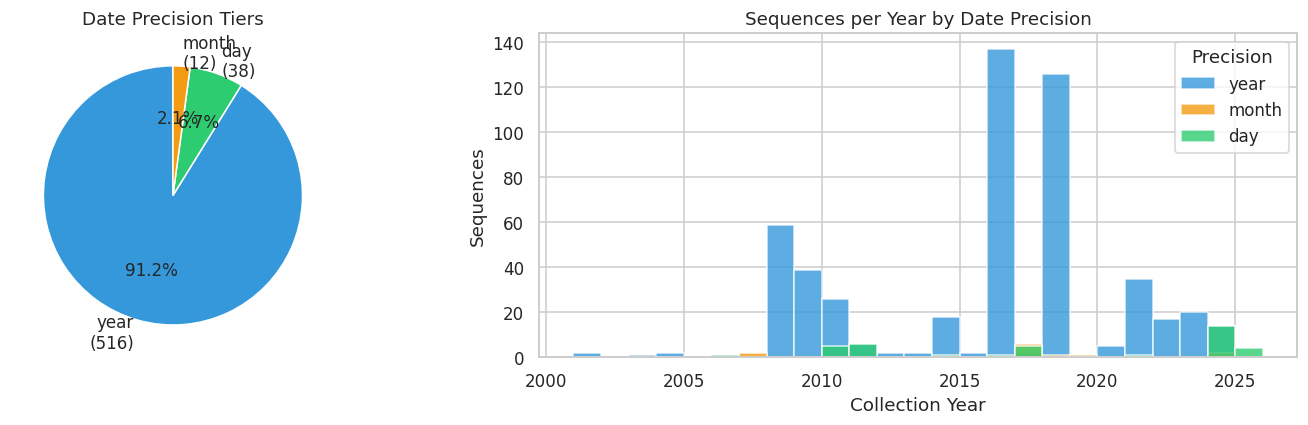

Green = exact date | Orange = month-precision | Blue = year-precision


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Precision breakdown pie
colors_pie = {'day': '#2ecc71', 'month': '#f39c12', 'year': '#3498db', 'unknown': '#e74c3c'}
pie_labels = [f"{p}\n({c})" for p, c in prec_counts.items()]
pie_colors = [colors_pie.get(p, 'grey') for p in prec_counts.index]
axes[0].pie(prec_counts.values, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Date Precision Tiers')

# Sequences per year, coloured by precision
for prec, color in [('year','#3498db'), ('month','#f39c12'), ('day','#2ecc71')]:
    sub = df[df['precision']==prec]['year'].dropna().astype(int)
    if len(sub):
        axes[1].hist(sub, bins=range(int(valid_years.min()), int(valid_years.max())+2),
                     color=color, edgecolor='white', alpha=0.8, label=prec)
axes[1].set_xlabel('Collection Year')
axes[1].set_ylabel('Sequences')
axes[1].set_title('Sequences per Year by Date Precision')
axes[1].legend(title='Precision')

plt.tight_layout()
plt.savefig('fig2_date_precision.png', bbox_inches='tight')
plt.show()
print('Green = exact date | Orange = month-precision | Blue = year-precision')

---
## Section 4 — Gap Analysis

In [8]:
gap_fractions = np.array([s.count('-') / aln_len for s in seqs_list])

warn_seqs = [(aln[i].id, gap_fractions[i]) for i in range(n_seq) if gap_fractions[i] >= GAP_WARN]
fail_seqs = [(aln[i].id, gap_fractions[i]) for i in range(n_seq) if gap_fractions[i] >= GAP_FAIL]

print('=' * 60)
print('  GAP ANALYSIS')
print('=' * 60)
print(f'  Mean gap fraction     : {gap_fractions.mean()*100:.2f}%')
print(f'  Median gap fraction   : {np.median(gap_fractions)*100:.2f}%')
print(f'  Max gap fraction      : {gap_fractions.max()*100:.2f}%  ({aln[int(np.argmax(gap_fractions))].id})')
print(f'  Sequences > {GAP_WARN*100:.0f}% gaps (warn)   : {len(warn_seqs)}')
print(f'  Sequences > {GAP_FAIL*100:.0f}% gaps (remove)  : {len(fail_seqs)}')
if fail_seqs:
    print(f'\n  ⚠  Sequences to consider removing:')
    for sid, gf in sorted(fail_seqs, key=lambda x: -x[1]):
        print(f'     {sid}: {gf*100:.1f}%')
else:
    print(f'  ✓  No sequences exceed {GAP_FAIL*100:.0f}% gap threshold')
print('=' * 60)

  GAP ANALYSIS
  Mean gap fraction     : 11.50%
  Median gap fraction   : 12.03%
  Max gap fraction      : 20.39%  (MZ447801)
  Sequences > 30% gaps (warn)   : 0
  Sequences > 50% gaps (remove)  : 0
  ✓  No sequences exceed 50% gap threshold


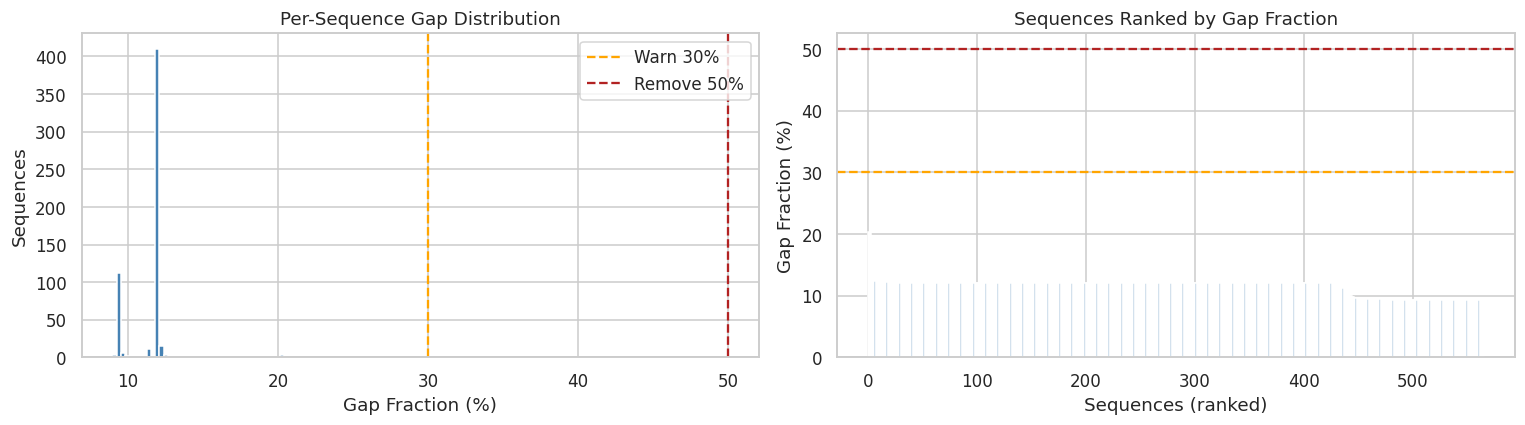

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(gap_fractions * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(GAP_WARN*100, color='orange', linestyle='--', label=f'Warn {GAP_WARN*100:.0f}%')
axes[0].axvline(GAP_FAIL*100, color='firebrick', linestyle='--', label=f'Remove {GAP_FAIL*100:.0f}%')
axes[0].set_xlabel('Gap Fraction (%)')
axes[0].set_ylabel('Sequences')
axes[0].set_title('Per-Sequence Gap Distribution')
axes[0].legend()

sorted_gaps = np.sort(gap_fractions)[::-1]
colors = ['firebrick' if g >= GAP_FAIL else ('orange' if g >= GAP_WARN else 'steelblue')
          for g in sorted_gaps]
axes[1].bar(range(len(sorted_gaps)), sorted_gaps * 100, color=colors, width=1.0)
axes[1].axhline(GAP_WARN*100, color='orange', linestyle='--')
axes[1].axhline(GAP_FAIL*100, color='firebrick', linestyle='--')
axes[1].set_xlabel('Sequences (ranked)')
axes[1].set_ylabel('Gap Fraction (%)')
axes[1].set_title('Sequences Ranked by Gap Fraction')

plt.tight_layout()
plt.savefig('fig3_gaps.png', bbox_inches='tight')
plt.show()

Computing column gap density...
  Columns with >50% gaps : 1082 / 8988 (12.0%)


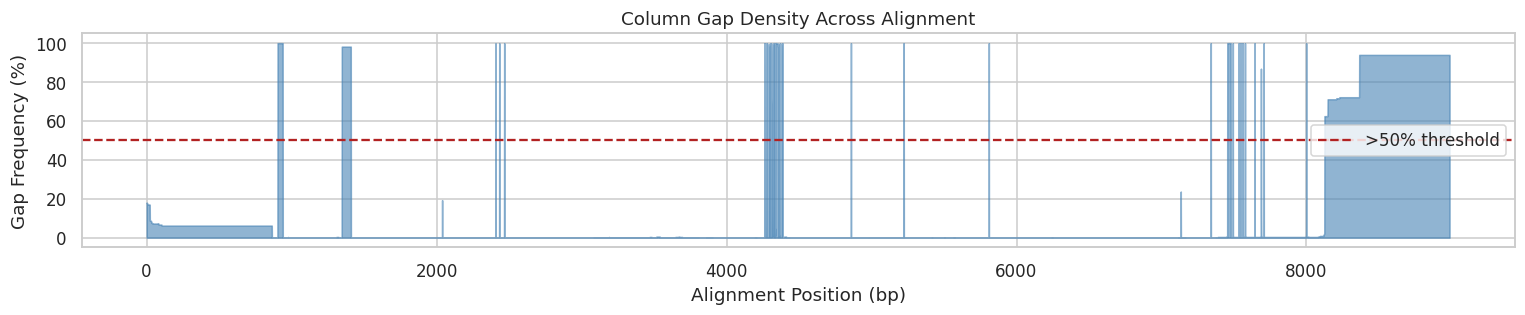

In [10]:
print('Computing column gap density...')
col_gap_frac = np.array([
    sum(1 for s in seqs_list if s[i] == '-') / n_seq
    for i in range(aln_len)
])
high_gap_cols = (col_gap_frac > 0.5).sum()
print(f'  Columns with >50% gaps : {high_gap_cols} / {aln_len} ({high_gap_cols/aln_len*100:.1f}%)')

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(range(aln_len), col_gap_frac * 100, color='steelblue', alpha=0.6)
ax.axhline(50, color='firebrick', linestyle='--', label='>50% threshold')
ax.set_xlabel('Alignment Position (bp)')
ax.set_ylabel('Gap Frequency (%)')
ax.set_title('Column Gap Density Across Alignment')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_col_gaps.png', bbox_inches='tight')
plt.show()

---
## Section 5 — Sequence Composition

  SEQUENCE COMPOSITION
  Mean GC content       : 36.56%
  GC std dev            : 0.08%
  GC range              : 35.8% – 36.8%
  High-ambiguity seqs   : 0
  ✓  No sequences exceed 5% ambiguity


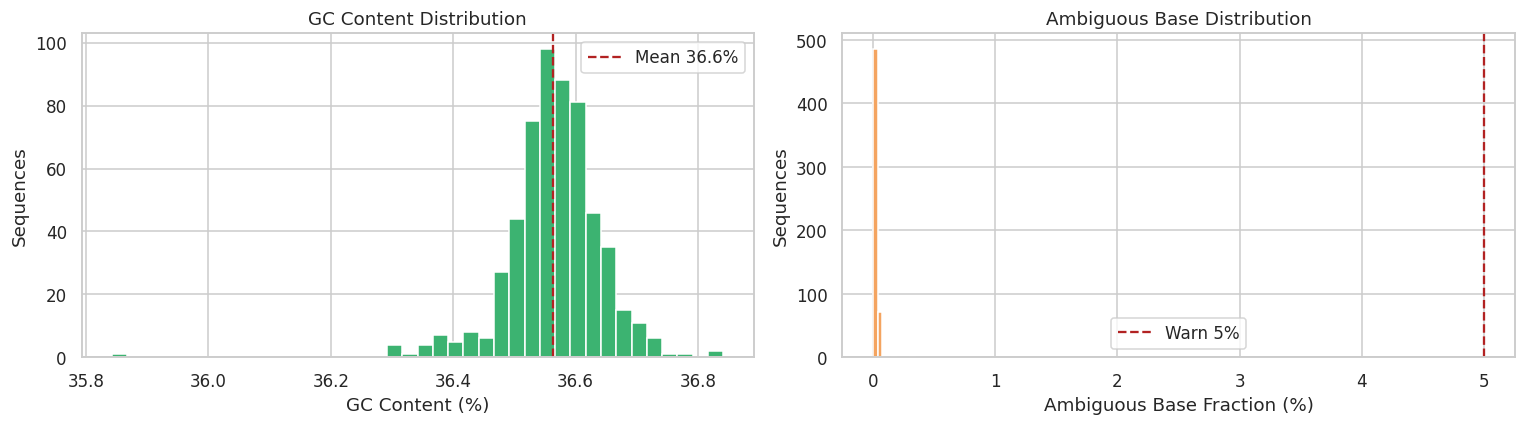

In [11]:
AMBIGUOUS = set('NRYWSKMBDHV')
gc_contents, amb_fractions = [], []

for s in seqs_list:
    no_gap = s.replace('-', '')
    if not no_gap:
        gc_contents.append(0); amb_fractions.append(0); continue
    gc_contents.append((no_gap.count('G') + no_gap.count('C')) / len(no_gap))
    amb_fractions.append(sum(no_gap.count(c) for c in AMBIGUOUS) / len(no_gap))

gc_contents   = np.array(gc_contents)
amb_fractions = np.array(amb_fractions)
high_amb = [(aln[i].id, amb_fractions[i]) for i in range(n_seq) if amb_fractions[i] > AMB_WARN]

print('=' * 60)
print('  SEQUENCE COMPOSITION')
print('=' * 60)
print(f'  Mean GC content       : {gc_contents.mean()*100:.2f}%')
print(f'  GC std dev            : {gc_contents.std()*100:.2f}%')
print(f'  GC range              : {gc_contents.min()*100:.1f}% – {gc_contents.max()*100:.1f}%')
print(f'  High-ambiguity seqs   : {len(high_amb)}')
if high_amb:
    for sid, af in sorted(high_amb, key=lambda x: -x[1])[:5]:
        print(f'    ⚠  {sid}: {af*100:.2f}%')
else:
    print(f'  ✓  No sequences exceed {AMB_WARN*100:.0f}% ambiguity')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(gc_contents*100, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].axvline(gc_contents.mean()*100, color='firebrick', linestyle='--',
                label=f'Mean {gc_contents.mean()*100:.1f}%')
axes[0].set_xlabel('GC Content (%)'); axes[0].set_ylabel('Sequences')
axes[0].set_title('GC Content Distribution'); axes[0].legend()

axes[1].hist(amb_fractions*100, bins=40, color='sandybrown', edgecolor='white')
axes[1].axvline(AMB_WARN*100, color='firebrick', linestyle='--', label=f'Warn {AMB_WARN*100:.0f}%')
axes[1].set_xlabel('Ambiguous Base Fraction (%)')
axes[1].set_ylabel('Sequences')
axes[1].set_title('Ambiguous Base Distribution'); axes[1].legend()

plt.tight_layout()
plt.savefig('fig5_composition.png', bbox_inches='tight')
plt.show()

---
## Section 6 — Pairwise Diversity

Computing pairwise distances (150 sampled)...
  PAIRWISE DIVERSITY
  Mean distance         : 4.21%
  Median distance       : 1.97%
  Max distance          : 21.87%
  ⚠  Pairs >20% divergence: 484 — possible contamination


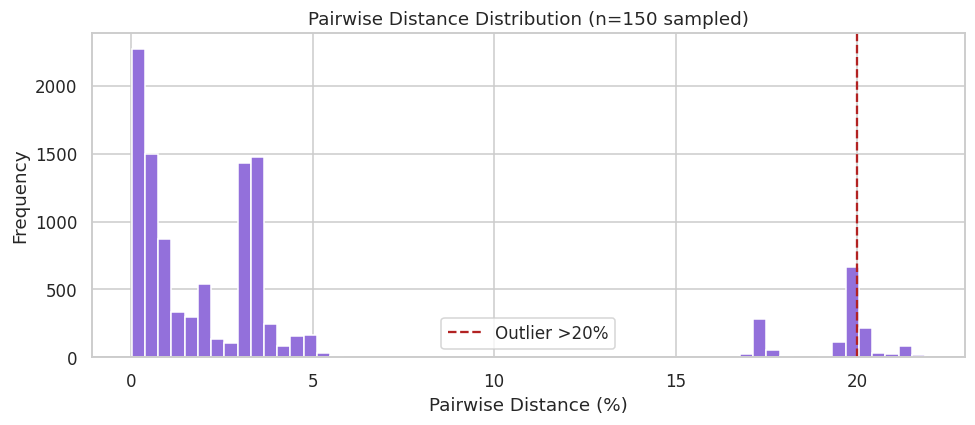

In [12]:
import random
random.seed(42)
SAMPLE_N = min(150, n_seq)
sampled_idx  = random.sample(range(n_seq), SAMPLE_N)
sampled_seqs = [seqs_list[i] for i in sampled_idx]
sampled_df   = df.iloc[sampled_idx].reset_index(drop=True)

def pdist(s1, s2):
    diff = total = 0
    for a, b in zip(s1, s2):
        if a == '-' and b == '-': continue
        total += 1
        if a != b: diff += 1
    return diff / total if total else 0

print(f'Computing pairwise distances ({SAMPLE_N} sampled)...')
dists = [pdist(sampled_seqs[i], sampled_seqs[j])
         for i in range(SAMPLE_N) for j in range(i+1, SAMPLE_N)]
dists = np.array(dists)

print('=' * 60)
print('  PAIRWISE DIVERSITY')
print('=' * 60)
print(f'  Mean distance         : {dists.mean()*100:.2f}%')
print(f'  Median distance       : {np.median(dists)*100:.2f}%')
print(f'  Max distance          : {dists.max()*100:.2f}%')
outlier_pairs = (dists > DIV_WARN).sum()
if outlier_pairs > 0:
    print(f'  ⚠  Pairs >20% divergence: {outlier_pairs} — possible contamination')
else:
    print(f'  ✓  All pairs within expected HPV16 range')
print('=' * 60)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dists*100, bins=60, color='mediumpurple', edgecolor='white')
ax.axvline(DIV_WARN*100, color='firebrick', linestyle='--', label=f'Outlier >{DIV_WARN*100:.0f}%')
ax.set_xlabel('Pairwise Distance (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Pairwise Distance Distribution (n={SAMPLE_N} sampled)')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_diversity.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Column Conservation

Analysing column conservation...
  COLUMN CONSERVATION
  Invariant columns     : 7393 (82.3%)
  Highly conserved >95% : 8823
  Variable <80%         : 31
  ℹ  High invariant fraction is expected for within-type HPV16 analysis
     BEAST handles this correctly via the +I (invariant sites) model


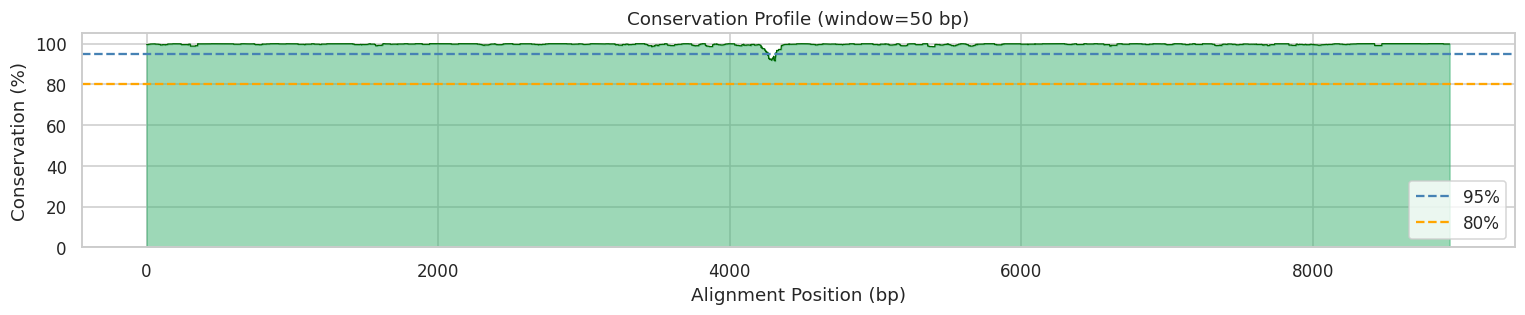

In [13]:
print('Analysing column conservation...')
conservation_scores = []
invariant_count = 0

for i in range(aln_len):
    col = ''.join(s[i] for s in seqs_list).replace('-', '')
    if not col:
        conservation_scores.append(0); continue
    freq = Counter(col).most_common(1)[0][1] / len(col)
    conservation_scores.append(freq)
    if len(set(col)) == 1:
        invariant_count += 1

conservation_scores = np.array(conservation_scores)
print('=' * 60)
print('  COLUMN CONSERVATION')
print('=' * 60)
print(f'  Invariant columns     : {invariant_count} ({invariant_count/aln_len*100:.1f}%)')
print(f'  Highly conserved >95% : {(conservation_scores>0.95).sum()}')
print(f'  Variable <80%         : {(conservation_scores<0.80).sum()}')
if invariant_count > aln_len * 0.80:
    print(f'  ℹ  High invariant fraction is expected for within-type HPV16 analysis')
    print(f'     BEAST handles this correctly via the +I (invariant sites) model')
else:
    print(f'  ✓  Good mix of invariant and variable sites')
print('=' * 60)

window = 50
smoothed = np.convolve(conservation_scores, np.ones(window)/window, mode='valid')
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(range(len(smoothed)), smoothed*100, color='mediumseagreen', alpha=0.5)
ax.plot(range(len(smoothed)), smoothed*100, color='darkgreen', linewidth=0.8)
ax.axhline(95, color='steelblue', linestyle='--', label='95%')
ax.axhline(80, color='orange', linestyle='--', label='80%')
ax.set_xlabel('Alignment Position (bp)')
ax.set_ylabel('Conservation (%)')
ax.set_title(f'Conservation Profile (window={window} bp)')
ax.set_ylim(0, 105); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig7_conservation.png', bbox_inches='tight')
plt.show()

---
## Section 8 — BEAST Readiness

### Temporal signal
Because 91%+ of sequences have **year-only precision** (dates artificially set to July 1st),
a simple regression of divergence vs year will be heavily distorted by date ties.

This section therefore runs **two separate tests**:
1. **Exact-date only** — regression on the subset with day-precision dates
2. **Year-level** — regression using integer years across all sequences

Neither replaces TempEst on an ML tree, but together they give a useful pre-BEAST signal check.

In [14]:
# Duplicate check
seq_counter = Counter(seqs_list)
duplicates  = {s: c for s, c in seq_counter.items() if c > 1}
print('=' * 60)
print('  DUPLICATE SEQUENCE CHECK')
print('=' * 60)
if duplicates:
    total_dupes = sum(c - 1 for c in duplicates.values())
    print(f'  ⚠  {total_dupes} duplicate sequence(s) found')
else:
    print('  ✓  No duplicates')
print('=' * 60)

  DUPLICATE SEQUENCE CHECK
  ✓  No duplicates


In [15]:
# Tip date format check
print('=' * 60)
print('  BEAST TIP DATE COMPATIBILITY')
print('=' * 60)
has_date = df['year'].notna().sum()
print(f'  Dates in description  : {has_date} / {n_seq}')
print()
print('  Sample tip labels:')
for rec in list(aln)[:4]:
    print(f'    > {rec.description}')
print()
if has_date == n_seq:
    print('  ✓  All sequences have dates')
    print()
    print('  ── BEAUti Tip Dates tab ──')
    print('  • Auto-configure → parse from header field 3 (index 2)')
    print('  • Date format: yyyy-MM-dd')
    print('  • Direction: Since some time in the past | Units: years')
    print()
    print('  ── Date uncertainty in BEAST ──')
    print('  Year-only sequences (July 1) carry ±6 months uncertainty.')
    print('  For a student project this is fine — BEAST will integrate')
    print('  over this uncertainty via the clock rate posterior.')
else:
    print(f'  ⚠  {n_seq - has_date} sequences missing dates')
print('=' * 60)

  BEAST TIP DATE COMPATIBILITY
  Dates in description  : 566 / 566

  Sample tip labels:
    > MK484705 | Human papillomavirus type 16 | 2018-07-01 | year | China
    > MW320358 | Human papillomavirus type 16 | 2017-06-15 | day | China
    > LC888271 | Human papillomavirus 16 | 2024-07-01 | year | Japan
    > LC718900 | Human papillomavirus 16 | 2021-07-01 | year | Japan

  ✓  All sequences have dates

  ── BEAUti Tip Dates tab ──
  • Auto-configure → parse from header field 3 (index 2)
  • Date format: yyyy-MM-dd
  • Direction: Since some time in the past | Units: years

  ── Date uncertainty in BEAST ──
  Year-only sequences (July 1) carry ±6 months uncertainty.
  For a student project this is fine — BEAST will integrate
  over this uncertainty via the clock rate posterior.


Building consensus and computing temporal signal...


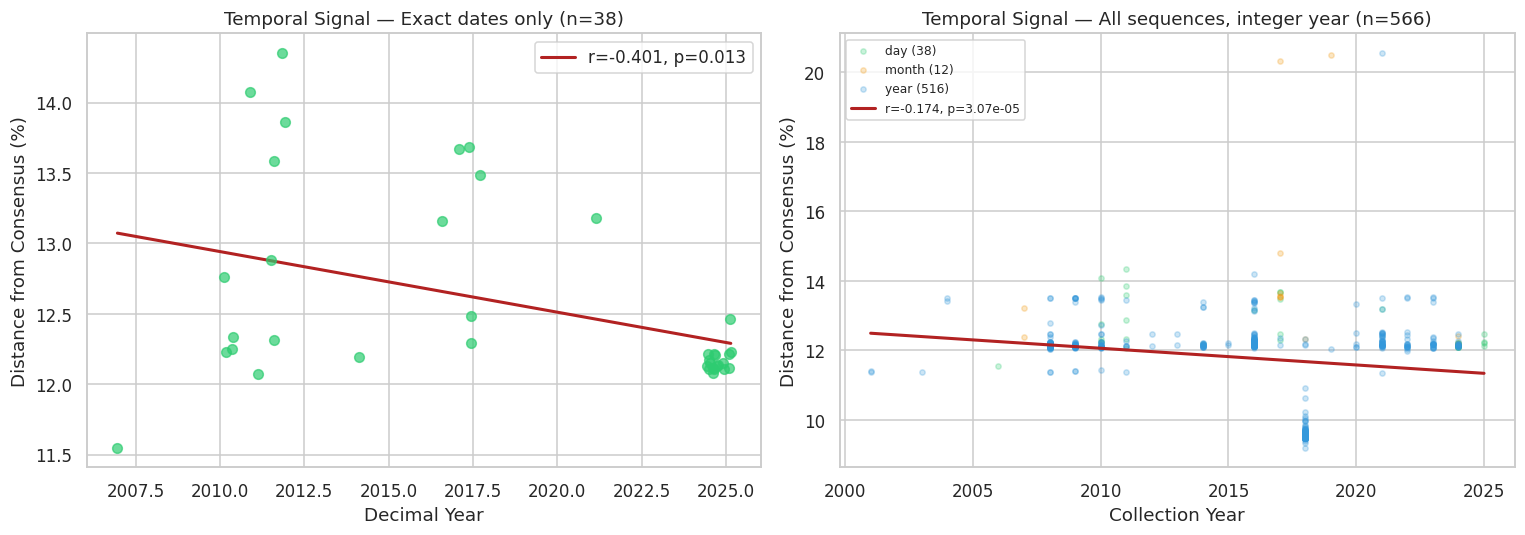

  TEMPORAL SIGNAL RESULTS
  Exact-date subset     : r=-0.4006, p=0.0127 (n=38)
  ⚠  Weak signal in exact dates — use TempEst for confirmation
  All sequences (yr)    : r=-0.1743, p=3.0683e-05 (n=566)

  ── Interpretation ──
  The all-sequences plot is distorted by year-precision ties (expected).
  The exact-date plot is the more reliable proxy.
  For a definitive test: run TempEst on an IQ-TREE ML tree.
  A positive slope in TempEst R² > 0.2 confirms clock signal.


In [16]:
# ── TEMPORAL SIGNAL ─────────────────────────────────────────────────────────
# Build consensus for distance proxy
print('Building consensus and computing temporal signal...')
consensus = ''.join(
    Counter(''.join(s[i] for s in seqs_list).replace('-','')).most_common(1)[0][0]
    if ''.join(s[i] for s in seqs_list).replace('-','') else 'N'
    for i in range(aln_len)
)

df_sig = df.copy()
df_sig['dist_consensus'] = [
    pdist(seqs_list[i], consensus) for i in range(n_seq)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: exact-date sequences only ──
exact = df_sig[df_sig['precision'] == 'day'].dropna(subset=['decimal', 'dist_consensus'])
if len(exact) >= 5:
    r_exact, p_exact = stats.pearsonr(exact['decimal'], exact['dist_consensus'])
    axes[0].scatter(exact['decimal'], exact['dist_consensus']*100,
                    alpha=0.7, s=40, color='#2ecc71', zorder=3)
    xs = np.linspace(exact['decimal'].min(), exact['decimal'].max(), 100)
    m, b = np.polyfit(exact['decimal'], exact['dist_consensus'], 1)
    axes[0].plot(xs, (m*xs+b)*100, color='firebrick', linewidth=2,
                 label=f'r={r_exact:.3f}, p={p_exact:.3f}')
    axes[0].set_title(f'Temporal Signal — Exact dates only (n={len(exact)})')
    axes[0].set_xlabel('Decimal Year')
    axes[0].set_ylabel('Distance from Consensus (%)')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, f'Only {len(exact)} exact-date sequences\n(need ≥5 for regression)',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Exact-date temporal signal (insufficient data)')
    r_exact, p_exact = None, None

# ── Plot 2: all sequences using integer year ──
all_sig = df_sig.dropna(subset=['year', 'dist_consensus'])
r_all, p_all = stats.pearsonr(all_sig['year'].astype(float), all_sig['dist_consensus'])

# colour by precision tier
color_map = {'year': '#3498db', 'month': '#f39c12', 'day': '#2ecc71'}
for prec, grp in all_sig.groupby('precision'):
    axes[1].scatter(grp['year'], grp['dist_consensus']*100,
                    alpha=0.25, s=12, color=color_map.get(prec, 'grey'),
                    label=f'{prec} ({len(grp)})')

xs2 = np.linspace(all_sig['year'].min(), all_sig['year'].max(), 100)
m2, b2 = np.polyfit(all_sig['year'].astype(float), all_sig['dist_consensus'], 1)
axes[1].plot(xs2, (m2*xs2+b2)*100, color='firebrick', linewidth=2,
             label=f'r={r_all:.3f}, p={p_all:.2e}')
axes[1].set_title(f'Temporal Signal — All sequences, integer year (n={len(all_sig)})')
axes[1].set_xlabel('Collection Year')
axes[1].set_ylabel('Distance from Consensus (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig8_temporal_signal.png', bbox_inches='tight')
plt.show()

print('=' * 60)
print('  TEMPORAL SIGNAL RESULTS')
print('=' * 60)
if r_exact is not None:
    print(f'  Exact-date subset     : r={r_exact:.4f}, p={p_exact:.4f} (n={len(exact)})')
    if r_exact > 0.2 and p_exact < 0.05:
        print('  ✓  Positive signal in exact-date sequences')
    else:
        print('  ⚠  Weak signal in exact dates — use TempEst for confirmation')
print(f'  All sequences (yr)    : r={r_all:.4f}, p={p_all:.4e} (n={len(all_sig)})')
print()
print('  ── Interpretation ──')
print('  The all-sequences plot is distorted by year-precision ties (expected).')
print('  The exact-date plot is the more reliable proxy.')
print('  For a definitive test: run TempEst on an IQ-TREE ML tree.')
print('  A positive slope in TempEst R² > 0.2 confirms clock signal.')
print('=' * 60)

---
## Final Verdict

In [17]:
issues   = []
warnings = []
passes   = []
info     = []

# Dates
if len(missing_date) == 0:
    passes.append('All sequences have collection dates')
else:
    issues.append(f'{len(missing_date)} sequences missing dates — required for BEAST')

# Date precision
year_only_n = prec_counts.get('year', 0)
info.append(f'Date precision: {prec_counts.get("day",0)} exact, '
            f'{prec_counts.get("month",0)} month, '
            f'{year_only_n} year-only (→ July 1 midpoint)')

# Temporal span
span = int(valid_years.max() - valid_years.min())
if span >= 5:
    passes.append(f'Temporal span adequate ({span} years)')
else:
    warnings.append(f'Short temporal span ({span} yrs)')

# Gaps
if len(fail_seqs) == 0:
    passes.append('No sequences exceed 50% gap threshold')
else:
    issues.append(f'{len(fail_seqs)} sequences with >50% gaps — remove before BEAST')

if len(warn_seqs) > 0:
    warnings.append(f'{len(warn_seqs)} sequences between 30-50% gaps — review individually')

# Ambiguity
if len(high_amb) == 0:
    passes.append('No high-ambiguity sequences')
else:
    warnings.append(f'{len(high_amb)} sequences exceed 5% ambiguous bases')

# Duplicates
if not duplicates:
    passes.append('No duplicate sequences')
else:
    issues.append('Duplicate sequences found — remove before BEAST')

# Divergence
if outlier_pairs == 0:
    passes.append('All pairwise distances within expected range')
else:
    warnings.append(f'{outlier_pairs} high-divergence pairs (>20%) — check for contamination')

# Conservation
if invariant_count > aln_len * 0.80:
    info.append('High invariant fraction (expected for within-type HPV16) — use GTR+G+I in BEAUti')

# Temporal signal
info.append('Temporal signal: verify with TempEst on ML tree before BEAUti (proxy tests unreliable with year-precision dates)')

# Print
print()
print('╔══════════════════════════════════════════════════════════╗')
print('║          HPV ALIGNMENT VALIDATION — FINAL VERDICT       ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  File: {FASTA_PATH:<50} ║')
print(f'║  Sequences: {n_seq}   |   Alignment: {aln_len:,} bp{" "*8}║')
print('╠══════════════════════════════════════════════════════════╣')
for p_ in passes:   print(f'║  ✓  {p_[:54]:<54} ║')
for w  in warnings: print(f'║  ⚠  {w[:54]:<54} ║')
for iss in issues:  print(f'║  ✗  {iss[:54]:<54} ║')
print('╠══════════════════════════════════════════════════════════╣')
for i_ in info:     print(f'║  ℹ  {i_[:54]:<54} ║')
print('╠══════════════════════════════════════════════════════════╣')

if not issues and not warnings:
    verdict, sym = 'READY FOR BEAST', '🟢'
elif not issues:
    verdict, sym = 'READY — review warnings before BEAUti', '🟡'
else:
    verdict, sym = 'NOT READY — resolve issues first', '🔴'

print(f'║  {sym}  {verdict:<54} ║')
print('╚══════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════╗
║          HPV ALIGNMENT VALIDATION — FINAL VERDICT       ║
╠══════════════════════════════════════════════════════════╣
║  File: hpv_aligned_mafft.fasta                            ║
║  Sequences: 566   |   Alignment: 8,988 bp        ║
╠══════════════════════════════════════════════════════════╣
║  ✓  All sequences have collection dates                    ║
║  ✓  Temporal span adequate (24 years)                      ║
║  ✓  No sequences exceed 50% gap threshold                  ║
║  ✓  No high-ambiguity sequences                            ║
║  ✓  No duplicate sequences                                 ║
║  ⚠  484 high-divergence pairs (>20%) — check for contamina ║
╠══════════════════════════════════════════════════════════╣
║  ℹ  Date precision: 38 exact, 12 month, 516 year-only (→ J ║
║  ℹ  High invariant fraction (expected for within-type HPV1 ║
║  ℹ  Temporal signal: verify with TempEst on ML tree before ║
╠════════════